In [47]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [48]:
class RNNScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_hidden, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.sigma = sigma

        # Init weights and biases
        self.Wxh = nn.Parameter(torch.randn(num_inputs, num_hidden) * sigma)
        self.Whh = nn.Parameter(torch.randn(num_hidden, num_hidden) * sigma)
        self.bh = nn.Parameter(torch.zeros(num_hidden))

In [49]:
# Forward pass
def forward(self, inputs, state=None):
    if state is None:
        state = torch.zeros((inputs.shape[1], self.num_hidden), device=inputs.device)
    else:
        state, = state

    outputs = []
    # Shape of inputs: (num_steps, batch_size, num_inputs)
    for X in inputs:
        state = torch.tanh(torch.matmul(X, self.Wxh) + torch.matmul(state, self.Whh) + self.bh)
        outputs.append(state)
    return outputs, state

RNNScratch.forward = forward

In [50]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

In [51]:
"""Language Based RNN"""
class RNNLM(d2l.Classifier):
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr
        self.init_params()

    def init_params(self):
        self.Whq = nn.Parameter(torch.randn(self.rnn.num_hidden, self.vocab_size) * self.rnn.sigma)
        self.bq = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

In [52]:
def one_hot(self, X):
    return F.one_hot(X.T, self.vocab_size).type(torch.float32)

RNNLM.one_hot = one_hot

In [53]:
def output_layer(self, rnn_output):
    outputs = [torch.matmul(H, self.Whq) + self.bq for H in rnn_output]
    return torch.stack(outputs, 1)

def forward(self, X, state=None):
    embs = self.one_hot(X)
    rnn_output, _ = self.rnn(embs, state)
    return self.output_layer(rnn_output)

RNNLM.output_layer = output_layer
RNNLM.forward = forward

In [54]:
def check_len(a, n):  #@save
    """Check the length of a list."""
    assert len(a) == n, f'list\'s length {len(a)} != expected length {n}'

def check_shape(a, shape):  #@save
    """Check the shape of a tensor."""
    assert a.shape == shape, \
            f'tensor\'s shape {a.shape} != expected shape {shape}'

check_len(outputs, num_steps)
check_shape(outputs[0], (batch_size, num_hiddens))
check_shape(state, (batch_size, num_hiddens))


In [55]:
"""Testing output shape"""

model = RNNLM(rnn, num_inputs)
outputs = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(outputs, (batch_size, num_steps, num_inputs))


In [80]:
"""Gradient Clipping"""
@d2l.add_to_class(d2l.Trainer) # add to trainer as opposed to model class
def clip_gradients(self, grad_clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > grad_clip_val:
        for p in params:
            p.grad[:] *= grad_clip_val / norm



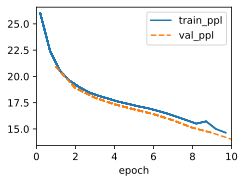

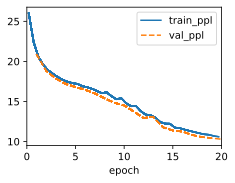

In [82]:
"""No Gradient Clipping"""
epochs = [10, 20]
for epoch in epochs:
    data = d2l.TimeMachine(batch_size=1024, num_steps=32)
    rnn = RNNScratch(num_inputs=len(data.vocab), num_hidden=32)
    model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
    trainer = d2l.Trainer(max_epochs=epoch, gradient_clip_val=1, num_gpus=1)
    trainer.fit(model, data)


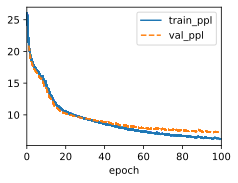

In [ ]:
"""Gradient Clipping"""
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hidden=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)


In [61]:
def predict(self, prefix, num_preds, vocab, device=None):
    state, outputs = None, [vocab[prefix[0]]]
    for i in range(len(prefix) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        embs = self.one_hot(X)
        rnn_outputs, state = self.rnn(embs, state)
        if i < len(prefix) - 1:  # Warm-up period
            outputs.append(vocab[prefix[i + 1]])
        else:  # Predict num_preds steps
            Y = self.output_layer(rnn_outputs)
            outputs.append(int(Y.argmax(axis=2).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

RNNLM.predict = predict

In [62]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has a fore the the the '

In [67]:
"""Now that I have implemented an RNN from scratch and LM model, I will calculate perplexity and perform hyperparameter tuning"""
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np
# Redefine basic RNN
class RNNScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_hidden, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.sigma = sigma

        # Init weights and biases
        self.Wxh = nn.Parameter(torch.randn(num_inputs, num_hidden) * sigma)
        self.Whh = nn.Parameter(torch.randn(num_hidden, num_hidden) * sigma)
        self.bh = nn.Parameter(torch.zeros(num_hidden))

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((inputs.shape[1], self.num_hidden), device=inputs.device)
        else:
            state, = state

        outputs = []
        # Shape of inputs: (num_steps, batch_size, num_inputs)
        for X in inputs:
            state = torch.tanh(torch.matmul(X, self.Wxh) + torch.matmul(state, self.Whh) + self.bh)
            outputs.append(state)
        return outputs, state
    
class RNNLM(d2l.Classifier):
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr
        self.init_params()

    def init_params(self):
        self.Whq = nn.Parameter(torch.randn(self.rnn.num_hidden, self.vocab_size) * self.rnn.sigma)
        self.bq = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

    def one_hot(self, X):
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)
    
    def output_layer(self, rnn_output):
        outputs = [torch.matmul(H, self.Whq) + self.bq for H in rnn_output]
        return torch.stack(outputs, 1)

    def forward(self, X, state=None):
        embs = self.one_hot(X)
        rnn_output, _ = self.rnn(embs, state)
        return self.output_layer(rnn_output)
    
    def predict(self, prefix, num_preds, vocab, device=None):
        state, outputs = None, [vocab[prefix[0]]]
        for i in range(len(prefix) + num_preds - 1):
            X = torch.tensor([[outputs[-1]]], device=device)
            embs = self.one_hot(X)
            rnn_outputs, state = self.rnn(embs, state)
            if i < len(prefix) - 1:  # Warm-up period
                outputs.append(vocab[prefix[i + 1]])
            else:  # Predict num_preds steps
                Y = self.output_layer(rnn_outputs)
                outputs.append(int(Y.argmax(axis=2).reshape(1)))
        return ''.join([vocab.idx_to_token[i] for i in outputs])

In [78]:
# Function to train the model
def train_rnn(model, train_loader, val_loader, criterion, optimizer, num_epochs, clip=None):
    train_perplexities, val_perplexities = [], []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, targets in train_loader:
            h = torch.zeros(1, inputs.size(0), model.rnn.num_hidden)  # Initialize hidden state
            optimizer.zero_grad()
            outputs, _ = model(inputs, h)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Apply gradient clipping
            if clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            
            optimizer.step()
            total_loss += loss.item()

        # Calculate perplexity
        train_perplexity = np.exp(total_loss / len(train_loader))
        train_perplexities.append(train_perplexity)

        # Validation perplexity
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                h = torch.zeros(1, inputs.size(0), model.rnn.num_hidden)
                outputs, _ = model(inputs, h)
                val_loss += criterion(outputs, targets).item()
        
        val_perplexity = np.exp(val_loss / len(val_loader))
        val_perplexities.append(val_perplexity)
        
        print(f'Epoch {epoch+1}, Train Perplexity: {train_perplexity:.4f}, Val Perplexity: {val_perplexity:.4f}')
    
    return train_perplexities, val_perplexities

In [ ]:
"""Gradient Clipping"""
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hidden=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [79]:

time_batches = [16, 32, 64]
hidden_sizes = [64, 128]  # Experiment with different hidden units
seq_lengths = [10, 20]  # Different time steps
learning_rates = [0.001, 0.005]
num_epochs = [25, 50, 100]

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

best_perplexity = float('inf')
best_config = None
best_train_perplexities, best_val_perplexities = None, None

# Iterate over different hyperparameter configurations
for hidden_size in hidden_sizes:
    for epoch in num_epochs:
        for lr in learning_rates:
            for time_steps in time_batches:
                data = d2l.TimeMachine(batch_size=1024, num_steps=time_steps)

                # Split data loaders
                train_loader = data.train_dataloader()
                val_loader = data.val_dataloader()

                print(f"Training RNN with hidden_size={hidden_size}, num_epochs={epoch}, lr={lr}, time_steps={time_steps}")

                rnn = RNNScratch(num_inputs=len(data.vocab), num_hidden=hidden_size)
                model = RNNLM(rnn, vocab_size=len(data.vocab), lr=lr)
                optimizer = optim.Adam(model.parameters(), lr=lr)

                # Assume `train_loader` and `val_loader` are defined
                train_perplexities, val_perplexities = train_rnn(
                    model, train_loader, val_loader, criterion, optimizer, epoch
                )

                if val_perplexities[-1] < best_perplexity:
                    best_perplexity = val_perplexities[-1]
                    best_config = (hidden_size, epoch, lr, time_steps)
                    best_train_perplexities = train_perplexities
                    best_val_perplexities = val_perplexities

# Plot results for the best model
plt.plot(best_train_perplexities, label="Train Perplexity")
plt.plot(best_val_perplexities, label="Validation Perplexity")
plt.xlabel("Epochs")
plt.ylabel("Perplexity")
plt.legend()
plt.title(f"Best Config: Hidden={best_config[0]}, Seq={best_config[1]}, LR={best_config[2]}")
plt.show()

Training RNN with hidden_size=64, num_epochs=25, lr=0.001, time_steps=16


ValueError: too many values to unpack (expected 2)